# 01 — Exploratory Data Analysis

Phase 1 EDA notebook. Goals:
- Verify raw Statcast ingestion
- Document class distributions for Model 1 and Model 2
- Identify null rates per column
- Check pitch type counts by pitcher
- Confirm no label leakage in raw data

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from ml.ingest import load_raw

RAW_DIR = Path("../data/raw")

# Load all years
years = [2021, 2022, 2023, 2024]
frames = [load_raw(y) for y in years]
df = pd.concat(frames, ignore_index=True)
print(f"Total rows: {len(df):,}")
print(f"Date range: {df['game_date'].min()} → {df['game_date'].max()}")
df.shape

Total rows: 3,073,685
Date range: 2021-03-15 → 2024-10-30


(3073685, 119)

In [2]:
# ── Model 1 label space ─────────────────────────────────────────────────────
# Map raw Statcast `description` to the 6-class pitch outcome taxonomy.
# This is a preview; ml/labels.py will be the authoritative mapping.

MODEL1_MAP = {
    # ball
    "ball": "ball",
    "blocked_ball": "ball",
    "pitchout": "ball",
    # called_strike
    "called_strike": "called_strike",
    # swinging_strike
    "swinging_strike": "swinging_strike",
    "swinging_strike_blocked": "swinging_strike",
    "missed_bunt": "swinging_strike",
    "foul_tip": "swinging_strike",
    # foul
    "foul": "foul",
    "foul_bunt": "foul",
    "foul_pitchout": "foul",
    # in_play
    "hit_into_play": "in_play",
    "hit_into_play_no_out": "in_play",
    "hit_into_play_score": "in_play",
    # hit_by_pitch
    "hit_by_pitch": "hit_by_pitch",
}

df["pitch_outcome_label"] = df["description"].map(MODEL1_MAP)
mapped = df["pitch_outcome_label"].notna()
print(f"Mapped: {mapped.sum():,} / {len(df):,} rows ({mapped.mean():.1%})")
print("\nUnmapped descriptions:")
print(df.loc[~mapped, "description"].value_counts().head(20))

Mapped: 3,063,816 / 3,073,685 rows (99.7%)

Unmapped descriptions:
description
automatic_ball      9268
automatic_strike     501
bunt_foul_tip        100
Name: count, dtype: int64


In [3]:
# ── Leakage check: confirm raw data has no derived label columns ──────────────
DERIVED_COLS = ["pitch_outcome_label", "bip_label", "model1_label", "model2_label"]
raw_df = load_raw(2021)
leaking = [c for c in DERIVED_COLS if c in raw_df.columns]
if leaking:
    print(f"WARNING: raw data contains derived columns: {leaking}")
else:
    print("OK: no derived label columns found in raw data — no leakage.")

OK: no derived label columns found in raw data — no leakage.


In [4]:
# ── Pitch type counts by pitcher (top 20 pitchers by volume) ─────────────────
pitch_counts = (
    df.groupby(["player_name", "pitch_type"])
    .size()
    .reset_index(name="count")
)
top_pitchers = (
    pitch_counts.groupby("player_name")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)
top_pitcher_pitches = pitch_counts[pitch_counts["player_name"].isin(top_pitchers)]
pivot = top_pitcher_pitches.pivot(index="player_name", columns="pitch_type", values="count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)
print("Pitch type counts for top 20 pitchers by volume:")
print(pivot.to_string())

Pitch type counts for top 20 pitchers by volume:
pitch_type         CH  CS    CU  FA    FC    FF    FS    KC  PO    SI    SL    ST    SV  total
player_name                                                                                   
Nola, Aaron      1963   0     0   0   859  4380     0  4024   0  2443     0     0     0  13669
Wheeler, Zack     184   0  1457   0  2350  5635   252     0   0  2374     1   909     0  13162
Cease, Dylan      422   0     0   0    19  5569     0  1666   0    28  4977   171     0  12852
Cole, Gerrit     1109   0     0   0   757  6147     0  1726   0    68  2564     0     0  12371
Gausman, Kevin    212   0     0   0     0  6278  4392     0   0   193  1199    26     0  12300
Burnes, Corbin   1265   0  2284   0  6376    41     0     0   1   956  1061   226     0  12210
Berríos, José    1917   0     0   0   109  2842     0     0   0  3651     1     0  3627  12147
Morton, Charlie  1033   0  4795   0   994  3944     0     0   0  1212     0     0     0  11978
C

In [5]:
# ── Top-10 null-rate columns ─────────────────────────────────────────────────
null_rates = df.isnull().mean().sort_values(ascending=False)
top_nulls = null_rates[null_rates > 0].head(10)
print("Top-10 columns by null rate:")
print(top_nulls.apply(lambda x: f"{x:.2%}").to_string())

Top-10 columns by null rate:
break_angle_deprecated     100.00%
break_length_deprecated    100.00%
spin_dir                   100.00%
spin_rate_deprecated       100.00%
tfs_zulu_deprecated        100.00%
umpire                     100.00%
sv_id                      100.00%
tfs_deprecated             100.00%
miss_distance               96.42%
on_3b                       90.48%


BIP rows: 543,141
Unmapped events: 5287
events
field_error       5252
catcher_interf      35
Name: count, dtype: int64

Model 2 — Ball-in-Play Outcome class distribution:
            count   pct
bip_label              
out        361396  67.2
single     113271  21.1
double      35303   6.6
home_run    24835   4.6
triple       3049   0.6


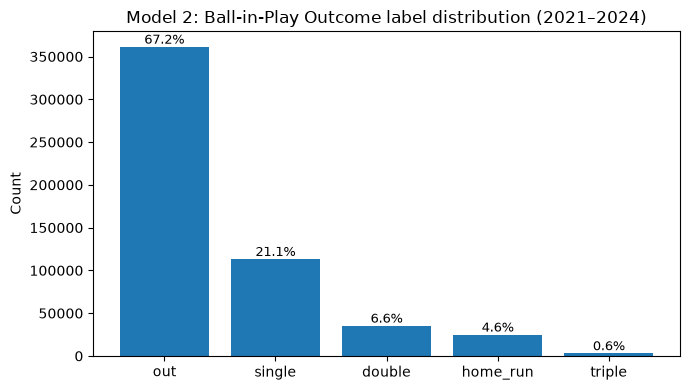

In [6]:
# ── Model 2 label space (in-play rows only) ──────────────────────────────────
MODEL2_MAP = {
    "single": "single",
    "double": "double",
    "triple": "triple",
    "home_run": "home_run",
    # All other in-play events → out
    "field_out": "out",
    "force_out": "out",
    "grounded_into_double_play": "out",
    "double_play": "out",
    "triple_play": "out",
    "sac_fly": "out",
    "sac_bunt": "out",
    "sac_fly_double_play": "out",
    "sac_bunt_double_play": "out",
    "fielders_choice": "out",
    "fielders_choice_out": "out",
    "other_out": "out",
}

bip = df[df["pitch_outcome_label"] == "in_play"].copy()
bip["bip_label"] = bip["events"].map(MODEL2_MAP)

unmapped_bip = bip["bip_label"].isna()
print(f"BIP rows: {len(bip):,}")
print(f"Unmapped events: {unmapped_bip.sum()}")
if unmapped_bip.sum() > 0:
    print(bip.loc[unmapped_bip, "events"].value_counts())

m2 = bip["bip_label"].dropna()
counts2 = m2.value_counts()
pct2 = (counts2 / len(m2) * 100).round(1)
print("\nModel 2 — Ball-in-Play Outcome class distribution:")
print(pd.DataFrame({"count": counts2, "pct": pct2}).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts2.index, counts2.values)
ax.set_title("Model 2: Ball-in-Play Outcome label distribution (2021–2024)")
ax.set_ylabel("Count")
for i, (_label, v) in enumerate(counts2.items()):
    ax.text(i, v + counts2.max() * 0.01, f"{v/len(m2):.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Model 1 — Pitch Outcome class distribution:
                       count   pct
pitch_outcome_label               
ball                 1082615  35.3
foul                  544166  17.8
in_play               543141  17.7
called_strike         500375  16.3
swinging_strike       384271  12.5
hit_by_pitch            9248   0.3


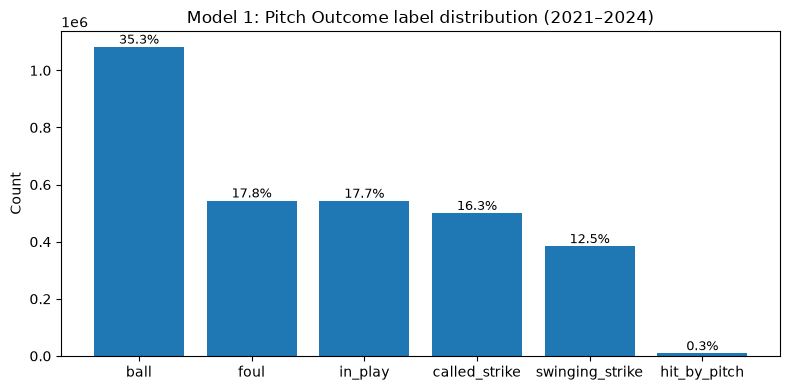

In [7]:
# ── Model 1: Class distribution ─────────────────────────────────────────────
m1 = df["pitch_outcome_label"].dropna()
counts = m1.value_counts()
pct = (counts / len(m1) * 100).round(1)
summary = pd.DataFrame({"count": counts, "pct": pct})
print("Model 1 — Pitch Outcome class distribution:")
print(summary.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(counts.index, counts.values)
ax.set_title("Model 1: Pitch Outcome label distribution (2021–2024)")
ax.set_ylabel("Count")
for i, (_label, v) in enumerate(counts.items()):
    ax.text(i, v + counts.max() * 0.01, f"{v/len(m1):.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()